In [2]:
!pip install lifelines
!pip install sympy==1.13.3

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# === Model & utilities (same core model as before, forward accepts concatenated input) ===

class RNNAFTGRU(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32, gru_layers=2, dropout=0.0):
        super().__init__()
        self.cov_dim = cov_dim
        self.input_dim = 1 + cov_dim
        self.hidden_dim = hidden_dim
        self.gru_layers = gru_layers

        self.gru = nn.GRU(
            input_size=self.input_dim,
            hidden_size=hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0.0
        )
        self.output = nn.Linear(hidden_dim, 1)
        self.init_fc = nn.Linear(cov_dim, gru_layers * hidden_dim)

    def initialize_hidden(self, X_static):
        h0_flat = torch.tanh(self.init_fc(X_static))
        h0 = h0_flat.view(self.gru_layers, X_static.size(0), self.hidden_dim)
        return h0

    def forward(self, X_in):
        # X_in: [batch, seq, 1 + cov_dim]
        covariates_seq = X_in[..., 1:]
        X_static = covariates_seq[:, 0, :]
        h0 = self.initialize_hidden(X_static)
        gru_out, h = self.gru(X_in, h0)
        yhat = self.output(gru_out).squeeze(-1)  # [batch, seq]
        return yhat, h

def batchify_subjects(subject_data: List[Dict], cov_dim: int):
    batch_size = len(subject_data)
    seq_lens = [len(s['log_gaps']) for s in subject_data]
    max_seq = max(seq_lens) if len(seq_lens) > 0 else 0
    prev_log_gaps = np.zeros((batch_size, max_seq, 1), dtype=np.float32)
    covariates = np.zeros((batch_size, max_seq, cov_dim), dtype=np.float32)
    log_gaps = np.zeros((batch_size, max_seq), dtype=np.float32)
    delta = np.zeros((batch_size, max_seq), dtype=np.float32)
    for i, s in enumerate(subject_data):
        l = seq_lens[i]
        if l == 0:
            continue
        if l > 1:
            prev_log_gaps[i, 1:l, 0] = s['log_gaps'][:-1]
        covariates[i, :l, :] = np.tile(s['covariates'], (l, 1))
        log_gaps[i, :l] = s['log_gaps']
        delta[i, :l] = s['delta']
    return (
        torch.tensor(prev_log_gaps, dtype=torch.float32),
        torch.tensor(covariates, dtype=torch.float32),
        torch.tensor(log_gaps, dtype=torch.float32),
        torch.tensor(delta, dtype=torch.float32),
        torch.tensor(seq_lens, dtype=torch.long)
    )

# === Gehan loss (full version left for reference) ===

class GehanLoss(nn.Module):
    """
    Original (full) Gehan loss that sums over all pairs. Kept for reference/testing.
    """
    def __init__(self, reduction='mean'):
        super().__init__()
        self.reduction = reduction

    def forward(self, pred_log_gaps, true_log_gaps, delta, seq_lens):
        device = pred_log_gaps.device
        batch, max_seq = pred_log_gaps.shape
        mask = (torch.arange(max_seq, device=device)[None, :] < seq_lens[:, None])
        events_mask = (delta == 1) & mask

        event_indices = events_mask.nonzero(as_tuple=False)
        if len(event_indices) == 0:
            return torch.tensor(0.0, requires_grad=True, device=device)

        e = true_log_gaps - pred_log_gaps  # residuals
        flat_e = e[mask]  # flatten only valid positions
        e_ij = e[event_indices[:, 0], event_indices[:, 1]]

        diffs = flat_e.unsqueeze(0) - e_ij.unsqueeze(1)  # [num_events, N_total]
        neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
        loss = neg_part.sum()
        if self.reduction == 'mean':
            loss = loss / event_indices.shape[0]
        return loss

# === Sub-sampling pairs utilities ===

def flatten_events(subjects: List[Dict]) -> Tuple[int, np.ndarray, np.ndarray, np.ndarray]:
    """
    Flatten events and provide mapping arrays.

    Returns:
      N_total: int (total number of event slots across subjects)
      subj_of_flat: np.array shape (N_total,) mapping flat_idx -> subject index i
      t_of_flat: np.array shape (N_total,) mapping flat_idx -> event time index j
      is_valid: np.array shape (N_total,) boolean - True if event exists (no padding)
    """
    seq_lens = [len(s['log_gaps']) for s in subjects]
    N_total = sum(seq_lens)
    subj_of_flat = np.empty(N_total, dtype=np.int32)
    t_of_flat = np.empty(N_total, dtype=np.int32)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1
    return N_total, subj_of_flat, t_of_flat

def sample_pairs_from_predictions(
    subjects: List[Dict],
    pred_log: np.ndarray,
    s: int,
    seed: int = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    For each uncensored residual (i,j) sample s indices from all other residuals
    (flat indexing). Returns arrays (I, J, L, K) each length m = n' * s, where
      (I[t], J[t]) is the left element (uncensored event),
      (L[t], K[t]) is the sampled counterpart.
    Sampling is uniform over other residuals excluding the same index.
    """
    rng = np.random.default_rng(seed)
    # Build flatten mapping and helpful arrays
    seq_lens = [len(su['log_gaps']) for su in subjects]
    prefix = np.concatenate([[0], np.cumsum(seq_lens)])
    N_total = int(prefix[-1])
    if N_total == 0:
        return (np.array([], dtype=int),) * 4

    # list of all flat indices
    all_flat = np.arange(N_total, dtype=int)

    # map from flat index to (i,j)
    subj_of_flat = np.empty(N_total, dtype=int)
    t_of_flat = np.empty(N_total, dtype=int)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1

    # gather uncensored flat indices
    uncensored_flats = []
    for i, ssub in enumerate(subjects):
        for j in range(len(ssub['log_gaps'])):
            if int(ssub['delta'][j]) == 1:
                flat_idx = prefix[i] + j
                uncensored_flats.append(flat_idx)
    uncensored_flats = np.array(uncensored_flats, dtype=int)
    n_prime = len(uncensored_flats)
    if n_prime == 0:
        return (np.array([], dtype=int),) * 4

    m = n_prime * s
    I = np.empty(m, dtype=int)
    J = np.empty(m, dtype=int)
    L = np.empty(m, dtype=int)
    K = np.empty(m, dtype=int)
    out_pos = 0
    for flat in uncensored_flats:
        # candidate pool excludes self
        pool = np.delete(all_flat, flat)
        replace = False if (pool.size >= s) else True
        chosen = rng.choice(pool, size=s, replace=replace)
        for ch in chosen:
            Ii = subj_of_flat[flat]
            Ji = t_of_flat[flat]
            Ll = subj_of_flat[ch]
            Kl = t_of_flat[ch]
            I[out_pos] = Ii
            J[out_pos] = Ji
            L[out_pos] = Ll
            K[out_pos] = Kl
            out_pos += 1
    return I, J, L, K

# === Metrics (unchanged from previous corrected implementation) ===

def pad_log_gaps(subjects, max_seq):
    n = len(subjects)
    arr = np.zeros((n, max_seq), dtype=np.float32)
    for i, s in enumerate(subjects):
        l = len(s['log_gaps'])
        arr[i, :l] = s['log_gaps']
    return arr

def compute_mse(subjects, pred_log):
    rows = []
    for i, subj in enumerate(subjects):
        for j in range(len(subj['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'log_gap': float(subj['log_gaps'][j]),
                'gap': float(np.exp(subj['log_gaps'][j])),
                'delta': int(subj['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    se = df['delta'] / df['G_hat'] * (df['log_gap'] - df['pred_log'])**2
    denom = df['delta'].sum()
    if denom == 0:
        return np.nan
    amse = se.sum() / denom
    return float(amse)

def ipcw_cindex(subjects, pred_log):
    rows = []
    for i, subj_i in enumerate(subjects):
        for j in range(len(subj_i['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'gap': float(np.exp(subj_i['log_gaps'][j])),
                'log_gap': float(subj_i['log_gaps'][j]),
                'delta': int(subj_i['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    num, denom = 0.0, 0.0
    for idx_i, row_i in df.iterrows():
        if row_i['delta'] != 1:
            continue
        for idx_k, row_k in df.iterrows():
            if row_i['i'] == row_k['i']:
                continue
            if row_i['gap'] < row_k['gap']:
                weight = 1.0 / row_i['G_hat'] if row_i['G_hat'] > 0 else 0.0
                concordant = 1.0 if row_i['pred_log'] < row_k['pred_log'] else 0.0
                num += weight * concordant
                denom += weight
    return float(num / denom) if denom > 0 else np.nan

# === Training with sub-sampled pairs ===

def train_rnn_aft_subsample_pairs(
    train_subjects,
    test_subjects,
    cov_dim=3,
    hidden_dim=32,
    epochs=10,
    pair_sample_s=2,
    pair_batch_b=64,
    lr=1e-3,
    device="cpu",
    seed=None
):
    device = torch.device(device)
    rng = np.random.default_rng(seed)
    model = RNNAFTGRU(cov_dim, hidden_dim=hidden_dim).to(device)
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    n_train = len(train_subjects)
    train_losses = []
    train_mse_hist = []
    test_mse_hist = []
    train_cidx_hist = []
    test_cidx_hist = []

    def predict_all_numpy(subjects):
        if len(subjects) == 0:
            return np.zeros((0, 0), dtype=np.float32)
        n = len(subjects)
        max_seq = max([len(s['log_gaps']) for s in subjects])
        X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(subjects, cov_dim)
        X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
        with torch.no_grad():
            yhat, _ = model(X_in)
        pred_log = yhat.cpu().numpy()
        out = np.zeros_like(pred_log)
        for i in range(n):
            out[i, :seq_lens[i]] = pred_log[i, :seq_lens[i]]
        return out

    for epoch in range(epochs):
        model.train()
        # Step 1: snapshot predictions to sample pairs (use numpy snapshot)
        pred_log_train_snapshot = predict_all_numpy(train_subjects)

        # Step 2: sample pairs (m = n' * s)
        I, J, L, K = sample_pairs_from_predictions(train_subjects, pred_log_train_snapshot, pair_sample_s, seed=rng.integers(1_000_000))
        m = I.size
        # If nothing was sampled (no uncensored events), fall back to no-op update pass
        if m == 0:
            print(f"Epoch {epoch+1}: no uncensored events found, skipping pair-subsampling updates.")
            train_losses.append(0.0)
            train_mse_hist.append(compute_mse(train_subjects, pred_log_train_snapshot))
            test_mse_hist.append(compute_mse(test_subjects, predict_all_numpy(test_subjects)))
            train_cidx_hist.append(ipcw_cindex(train_subjects, pred_log_train_snapshot))
            test_cidx_hist.append(ipcw_cindex(test_subjects, predict_all_numpy(test_subjects)))
            continue

        # shuffle sampled pairs
        perm_pairs = rng.permutation(m)
        I, J, L, K = I[perm_pairs], J[perm_pairs], L[perm_pairs], K[perm_pairs]

        # Precompute some constants for weighting
        N_total = sum(len(s['log_gaps']) for s in train_subjects)
        # number of uncensored events n'
        n_prime = int(np.sum([np.sum(s['delta']) for s in train_subjects]))

        # per-epoch optimization over sampled pairs mini-batches
        losses_epoch = []
        # iterate mini-batches of pairs
        for start in range(0, m, pair_batch_b):
            end = min(start + pair_batch_b, m)
            batch_slice = slice(start, end)
            Ib, Jb, Lb, Kb = I[batch_slice], J[batch_slice], L[batch_slice], K[batch_slice]

            # find unique subject indices in this pairs-batch
            unique_subjects, inv_idx = np.unique(np.concatenate([Ib, Lb]), return_inverse=True)
            # map global subject idx -> local index
            g2l = {int(g): int(l) for l, g in enumerate(unique_subjects)}
            # build small sub-batch of subjects
            sub_subjects = [train_subjects[int(g)] for g in unique_subjects]
            X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(sub_subjects, cov_dim)
            X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
            Y_log_gaps = Y_log_gaps.to(device)
            Y_delta = Y_delta.to(device)
            seq_lens_t = seq_lens.to(device)

            optimizer.zero_grad()
            yhat_sub, _ = model(X_in)  # [n_sub, max_sub_seq]
            # For each pair we need predicted log for left and right
            # Build tensors of predictions corresponding to pairs
            left_preds = []
            right_preds = []
            left_trues = []
            right_trues = []
            for idx_pair in range(Ib.size):
                gi = int(Ib[idx_pair]); gj = int(Jb[idx_pair])
                gl = int(Lb[idx_pair]); gk = int(Kb[idx_pair])
                li = g2l[gi]; ll = g2l[gl]
                # grab as torch scalars
                # Note: ensure event index within seq_lens for sub-batch (should be by construction)
                pred_ij = yhat_sub[li, gj]
                pred_lk = yhat_sub[ll, gk]
                left_preds.append(pred_ij)
                right_preds.append(pred_lk)
                left_trues.append(torch.tensor(float(train_subjects[gi]['log_gaps'][gj]), device=device))
                right_trues.append(torch.tensor(float(train_subjects[gl]['log_gaps'][gk]), device=device))
            left_preds = torch.stack(left_preds)  # [batch_pairs_in_minibatch]
            right_preds = torch.stack(right_preds)
            left_trues = torch.stack(left_trues)
            right_trues = torch.stack(right_trues)

            # residuals e = true - pred
            e_ij = left_trues - left_preds
            e_lk = right_trues - right_preds
            diffs = e_lk - e_ij
            neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
            sum_neg = neg_part.sum()

            # scaling for unbiased estimator:
            # For each uncensored event we sampled s from N_total - 1 possibilities. So factor = (N_total - 1) / s
            # Our overall GehanLoss with reduction='mean' divides by n' (#uncensored events).
            scale = float((N_total - 1) / max(1, pair_sample_s))
            loss_batch = sum_neg * scale
            if n_prime > 0:
                loss_batch = loss_batch / float(n_prime)
            # backpropagate
            loss_batch.backward()
            optimizer.step()
            losses_epoch.append(float(loss_batch.detach().cpu().numpy()))

        mean_epoch_loss = float(np.mean(losses_epoch)) if len(losses_epoch) > 0 else 0.0
        train_losses.append(mean_epoch_loss)

        # Evaluate on train and test sets (use current model to predict)
        model.eval()
        pred_log_train = predict_all_numpy(train_subjects)
        pred_log_test = predict_all_numpy(test_subjects)
        mse_train = compute_mse(train_subjects, pred_log_train)
        mse_test = compute_mse(test_subjects, predict_all_numpy(test_subjects))
        train_mse_hist.append(mse_train)
        test_mse_hist.append(mse_test)
        cidx_train = ipcw_cindex(train_subjects, pred_log_train)
        cidx_test = ipcw_cindex(test_subjects, predict_all_numpy(test_subjects))
        train_cidx_hist.append(cidx_train)
        test_cidx_hist.append(cidx_test)

        print(f"Epoch {epoch + 1}/{epochs} | SamplePairs m={m} | Mean Pair-Batch Loss: {mean_epoch_loss:.4f} | Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f} | Train C-index: {np.nan_to_num(cidx_train):.3f} | Test C-index: {np.nan_to_num(cidx_test):.3f}")

    # final evaluation
    model.eval()
    pred_log_train = predict_all_numpy(train_subjects)
    pred_log_test = predict_all_numpy(test_subjects)
    mse_train = compute_mse(train_subjects, pred_log_train)
    mse_test = compute_mse(test_subjects, pred_log_test)
    cidx_train = ipcw_cindex(train_subjects, pred_log_train)
    cidx_test = ipcw_cindex(test_subjects, pred_log_test)

    return {
        "model": model,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "cindex_train": cidx_train,
        "cindex_test": cidx_test,
        "pred_log_train": pred_log_train,
        "pred_log_test": pred_log_test,
        "train_losses": train_losses,
        "train_mse_hist": train_mse_hist,
        "test_mse_hist": test_mse_hist,
        "train_cidx_hist": train_cidx_hist,
        "test_cidx_hist": test_cidx_hist,
    }


# === Step 1: Load and Prepare the Dataset ===
def load_and_prepare_dataset(file_path, time_fixed_columns, gap_time_column, event_column):
    """
    Load the dataset and extract the relevant columns.

    Parameters:
        file_path: str
            Path to the CSV file containing the dataset.
        time_fixed_columns: list of str
            List of names for the time-fixed covariates.
        gap_time_column: str
            Name of the gap time column.
        event_column: str
            Name of the censoring status column (1 = observed, 0 = censored).

    Returns:
        dataset: pd.DataFrame
            A preprocessed DataFrame with the necessary columns.
    """
    # Load the dataset
    dataset = pd.read_csv(file_path)

    # Keep only the relevant columns
    dataset = dataset[time_fixed_columns + [gap_time_column, event_column]]

    # Rename columns for consistency
    dataset.columns = time_fixed_columns + ["gap_time", "event"]

    return dataset

# === Step 2: Convert the Dataset into Gaps and NN-Compatible Format ===
def prepare_data_for_nn(dataset, time_fixed_columns=("Z1", "Z2", "Z3")):
    """
    Prepare the dataset for use with the RNN-AFT model.

    Parameters:
        dataset: pd.DataFrame
            The dataset containing covariates, gap times, and event indicators.
        time_fixed_columns: list of str
            List of names for the time-fixed covariates.

    Returns:
        subjects: list of dict
            List of dictionaries formatted for the RNN-AFT model.
    """
    subjects = []
    for _, row in dataset.iterrows():
        covariates = row[time_fixed_columns].values.astype(np.float32)
        log_gaps = [np.log(row["gap_time"])]
        delta = [int(row["event"])]  # 1 (observed) or 0 (censored)
        subjects.append({
            "covariates": covariates,
            "log_gaps": log_gaps,
            "delta": delta,
        })
    return subjects

# === Step 3: Main Runner to Train the Model ===
def train_rnn_aft_on_real_data(
    dataset_path, time_fixed_columns, gap_time_column, event_column,
    train_split=0.7, hidden_dim=32, epochs=10, pair_sample_s=10,
    pair_batch_b=64, lr=1e-3, device="cpu", seed=42
):
    """
    Train the RNN-AFT model on a real dataset using only time-fixed covariates.

    Parameters:
        dataset_path: str
            Path to the dataset CSV file.
        time_fixed_columns: list of str
            List of names for time-fixed covariates (e.g., ["Z1", "Z2", "Z3"]).
        gap_time_column: str
            Name of the gap time column.
        event_column: str
            Name of the censoring status column.
        train_split: float
            Proportion of data to use for training.
        hidden_dim: int
            Number of GRU hidden dimensions.
        epochs: int
            Number of training epochs.
        pair_sample_s: int
            Number of pairs per uncensored residual.
        pair_batch_b: int
            Mini-batch size during training.
        lr: float
            Learning rate.
        device: str
            Device to run the model (e.g., "cpu" or "cuda").
        seed: int
            Random seed for reproducibility.
    """
    # Load and preprocess the dataset
    dataset = load_and_prepare_dataset(
        dataset_path, time_fixed_columns, gap_time_column, event_column
    )

    # Split into train and test sets
    train_data, test_data = train_test_split(dataset, train_size=train_split, random_state=seed)

    # Convert data to NN-compatible format
    train_subjects = prepare_data_for_nn(train_data, time_fixed_columns)
    test_subjects = prepare_data_for_nn(test_data, time_fixed_columns)

    # Train the RNN-AFT model
    results = train_rnn_aft_subsample_pairs(
        train_subjects, test_subjects,
        cov_dim=len(time_fixed_columns), hidden_dim=hidden_dim, epochs=epochs,
        pair_sample_s=pair_sample_s, pair_batch_b=pair_batch_b, lr=lr, device=device, seed=seed
    )

    # Print results
    print("\nFinal Results:")
    print(f"Train MSE: {results['mse_train']:.4f}")
    print(f"Test MSE: {results['mse_test']:.4f}")
    print(f"Train IPCW C-index: {results['cindex_train']:.4f}")
    print(f"Test IPCW C-index: {results['cindex_test']:.4f}")

    return results


# === Example Usage ===
if __name__ == "__main__":
    dataset_path = "/content/drive/MyDrive/Colab Notebooks/data_cp.csv"  # Replace "data.csv" with the name of your file
    time_fixed_columns = ["Z1", "Z2", "Z3"]  # Select time-fixed covariates
    gap_time_column = "gap_time"  # Name of the gap times column
    event_column = "event"  # Name of the censoring status column (1 = observed, 0 = censored)

    # Train the RNN-AFT model on the dataset
    results = train_rnn_aft_on_real_data(
        dataset_path, time_fixed_columns, gap_time_column, event_column,
        train_split=0.7, hidden_dim=32, epochs=10, pair_sample_s=25,
        pair_batch_b=64, lr=3e-4, device="cpu", seed=42
    )



Epoch 1/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.9207 | Train MSE: 69.5413 | Test MSE: 39.5670 | Train C-index: 0.502 | Test C-index: 0.535
Epoch 2/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.9620 | Train MSE: 71.1602 | Test MSE: 40.3719 | Train C-index: 0.579 | Test C-index: 0.602
Epoch 3/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.9189 | Train MSE: 72.2194 | Test MSE: 41.2791 | Train C-index: 0.592 | Test C-index: 0.620
Epoch 4/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.8810 | Train MSE: 72.8547 | Test MSE: 42.1481 | Train C-index: 0.611 | Test C-index: 0.626
Epoch 5/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.6226 | Train MSE: 74.0183 | Test MSE: 43.2540 | Train C-index: 0.614 | Test C-index: 0.628
Epoch 6/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.7916 | Train MSE: 72.2141 | Test MSE: 43.4870 | Train C-index: 0.612 | Test C-index: 0.630
Epoch 7/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.7376 | Train MSE: 71.7753 | Test MSE: 43.4882 | 

Loading and preparing the dataset...
Training the RNN-AFT model...
Epoch 1/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.9082 | Train MSE: 68.8422 | Test MSE: 39.1289 | Train C-index: 0.535 | Test C-index: 0.552
Epoch 2/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.9333 | Train MSE: 70.8785 | Test MSE: 40.3826 | Train C-index: 0.603 | Test C-index: 0.611
Epoch 3/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.8857 | Train MSE: 71.7978 | Test MSE: 41.3909 | Train C-index: 0.607 | Test C-index: 0.622
Epoch 4/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.8396 | Train MSE: 73.1325 | Test MSE: 42.9665 | Train C-index: 0.616 | Test C-index: 0.626
Epoch 5/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.5932 | Train MSE: 73.7821 | Test MSE: 43.8152 | Train C-index: 0.616 | Test C-index: 0.629
Epoch 6/10 | SamplePairs m=7975 | Mean Pair-Batch Loss: 4.7743 | Train MSE: 72.6400 | Test MSE: 44.1335 | Train C-index: 0.615 | Test C-index: 0.630
Epoch 7/10 | SamplePairs m=7975 | Mean 

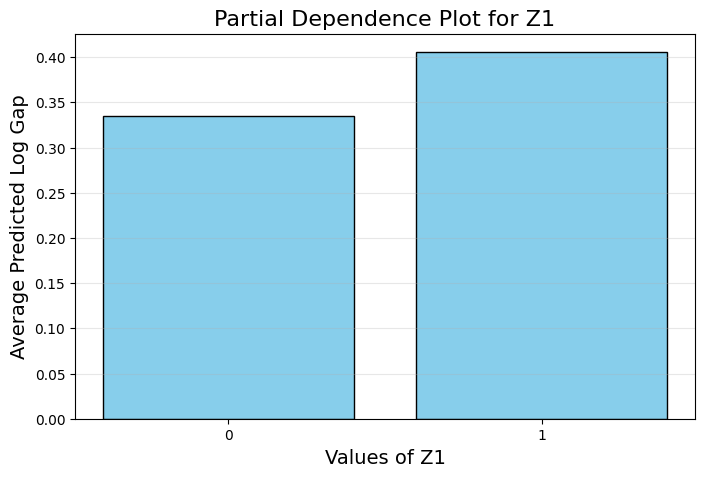

Generating PDP for Z2...


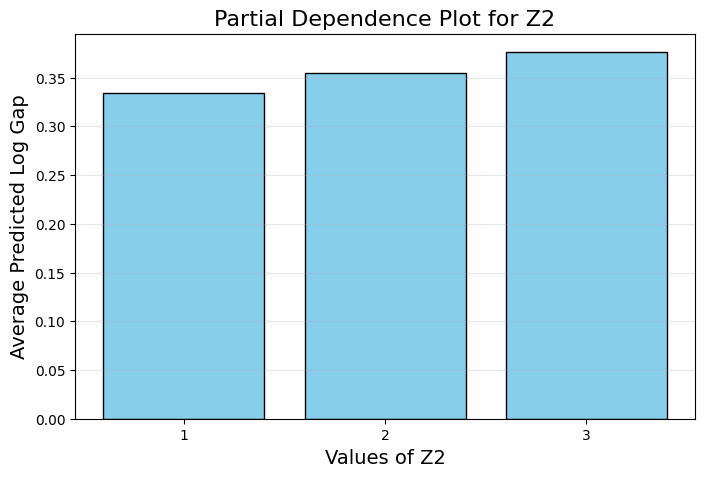

Generating PDP for Z3...


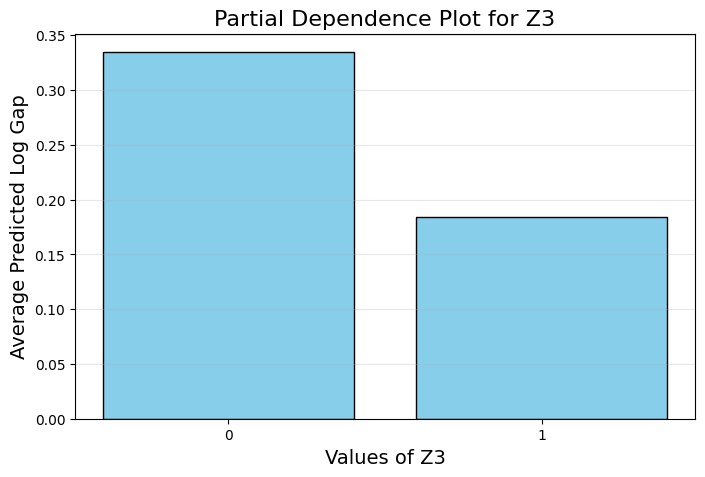

All Partial Dependence Plots have been generated.


In [ ]:

!pip install lifelines
!pip install sympy==1.13.3

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# === Model & utilities (same core model as before, forward accepts concatenated input) ===

class RNNAFTGRU(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32, gru_layers=2, dropout=0.0):
        super().__init__()
        self.cov_dim = cov_dim
        self.input_dim = 1 + cov_dim
        self.hidden_dim = hidden_dim
        self.gru_layers = gru_layers

        self.gru = nn.GRU(
            input_size=self.input_dim,
            hidden_size=hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0.0
        )
        self.output = nn.Linear(hidden_dim, 1)
        self.init_fc = nn.Linear(cov_dim, gru_layers * hidden_dim)

    def initialize_hidden(self, X_static):
        h0_flat = torch.tanh(self.init_fc(X_static))
        h0 = h0_flat.view(self.gru_layers, X_static.size(0), self.hidden_dim)
        return h0

    def forward(self, X_in):
        # X_in: [batch, seq, 1 + cov_dim]
        covariates_seq = X_in[..., 1:]
        X_static = covariates_seq[:, 0, :]
        h0 = self.initialize_hidden(X_static)
        gru_out, h = self.gru(X_in, h0)
        yhat = self.output(gru_out).squeeze(-1)  # [batch, seq]
        return yhat, h

def batchify_subjects(subject_data: List[Dict], cov_dim: int):
    batch_size = len(subject_data)
    seq_lens = [len(s['log_gaps']) for s in subject_data]
    max_seq = max(seq_lens) if len(seq_lens) > 0 else 0
    prev_log_gaps = np.zeros((batch_size, max_seq, 1), dtype=np.float32)
    covariates = np.zeros((batch_size, max_seq, cov_dim), dtype=np.float32)
    log_gaps = np.zeros((batch_size, max_seq), dtype=np.float32)
    delta = np.zeros((batch_size, max_seq), dtype=np.float32)
    for i, s in enumerate(subject_data):
        l = seq_lens[i]
        if l == 0:
            continue
        if l > 1:
            prev_log_gaps[i, 1:l, 0] = s['log_gaps'][:-1]
        covariates[i, :l, :] = np.tile(s['covariates'], (l, 1))
        log_gaps[i, :l] = s['log_gaps']
        delta[i, :l] = s['delta']
    return (
        torch.tensor(prev_log_gaps, dtype=torch.float32),
        torch.tensor(covariates, dtype=torch.float32),
        torch.tensor(log_gaps, dtype=torch.float32),
        torch.tensor(delta, dtype=torch.float32),
        torch.tensor(seq_lens, dtype=torch.long)
    )

# === Gehan loss (full version left for reference) ===

class GehanLoss(nn.Module):
    """
    Original (full) Gehan loss that sums over all pairs. Kept for reference/testing.
    """
    def __init__(self, reduction='mean'):
        super().__init__()
        self.reduction = reduction

    def forward(self, pred_log_gaps, true_log_gaps, delta, seq_lens):
        device = pred_log_gaps.device
        batch, max_seq = pred_log_gaps.shape
        mask = (torch.arange(max_seq, device=device)[None, :] < seq_lens[:, None])
        events_mask = (delta == 1) & mask

        event_indices = events_mask.nonzero(as_tuple=False)
        if len(event_indices) == 0:
            return torch.tensor(0.0, requires_grad=True, device=device)

        e = true_log_gaps - pred_log_gaps  # residuals
        flat_e = e[mask]  # flatten only valid positions
        e_ij = e[event_indices[:, 0], event_indices[:, 1]]

        diffs = flat_e.unsqueeze(0) - e_ij.unsqueeze(1)  # [num_events, N_total]
        neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
        loss = neg_part.sum()
        if self.reduction == 'mean':
            loss = loss / event_indices.shape[0]
        return loss

# === Sub-sampling pairs utilities ===

def flatten_events(subjects: List[Dict]) -> Tuple[int, np.ndarray, np.ndarray, np.ndarray]:
    """
    Flatten events and provide mapping arrays.

    Returns:
      N_total: int (total number of event slots across subjects)
      subj_of_flat: np.array shape (N_total,) mapping flat_idx -> subject index i
      t_of_flat: np.array shape (N_total,) mapping flat_idx -> event time index j
      is_valid: np.array shape (N_total,) boolean - True if event exists (no padding)
    """
    seq_lens = [len(s['log_gaps']) for s in subjects]
    N_total = sum(seq_lens)
    subj_of_flat = np.empty(N_total, dtype=np.int32)
    t_of_flat = np.empty(N_total, dtype=np.int32)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1
    return N_total, subj_of_flat, t_of_flat

def sample_pairs_from_predictions(
    subjects: List[Dict],
    pred_log: np.ndarray,
    s: int,
    seed: int = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    For each uncensored residual (i,j) sample s indices from all other residuals
    (flat indexing). Returns arrays (I, J, L, K) each length m = n' * s, where
      (I[t], J[t]) is the left element (uncensored event),
      (L[t], K[t]) is the sampled counterpart.
    Sampling is uniform over other residuals excluding the same index.
    """
    rng = np.random.default_rng(seed)
    # Build flatten mapping and helpful arrays
    seq_lens = [len(su['log_gaps']) for su in subjects]
    prefix = np.concatenate([[0], np.cumsum(seq_lens)])
    N_total = int(prefix[-1])
    if N_total == 0:
        return (np.array([], dtype=int),) * 4

    # list of all flat indices
    all_flat = np.arange(N_total, dtype=int)

    # map from flat index to (i,j)
    subj_of_flat = np.empty(N_total, dtype=int)
    t_of_flat = np.empty(N_total, dtype=int)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1

    # gather uncensored flat indices
    uncensored_flats = []
    for i, ssub in enumerate(subjects):
        for j in range(len(ssub['log_gaps'])):
            if int(ssub['delta'][j]) == 1:
                flat_idx = prefix[i] + j
                uncensored_flats.append(flat_idx)
    uncensored_flats = np.array(uncensored_flats, dtype=int)
    n_prime = len(uncensored_flats)
    if n_prime == 0:
        return (np.array([], dtype=int),) * 4

    m = n_prime * s
    I = np.empty(m, dtype=int)
    J = np.empty(m, dtype=int)
    L = np.empty(m, dtype=int)
    K = np.empty(m, dtype=int)
    out_pos = 0
    for flat in uncensored_flats:
        # candidate pool excludes self
        pool = np.delete(all_flat, flat)
        replace = False if (pool.size >= s) else True
        chosen = rng.choice(pool, size=s, replace=replace)
        for ch in chosen:
            Ii = subj_of_flat[flat]
            Ji = t_of_flat[flat]
            Ll = subj_of_flat[ch]
            Kl = t_of_flat[ch]
            I[out_pos] = Ii
            J[out_pos] = Ji
            L[out_pos] = Ll
            K[out_pos] = Kl
            out_pos += 1
    return I, J, L, K

# === Metrics (unchanged from previous corrected implementation) ===

def pad_log_gaps(subjects, max_seq):
    n = len(subjects)
    arr = np.zeros((n, max_seq), dtype=np.float32)
    for i, s in enumerate(subjects):
        l = len(s['log_gaps'])
        arr[i, :l] = s['log_gaps']
    return arr

def compute_mse(subjects, pred_log):
    rows = []
    for i, subj in enumerate(subjects):
        for j in range(len(subj['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'log_gap': float(subj['log_gaps'][j]),
                'gap': float(np.exp(subj['log_gaps'][j])),
                'delta': int(subj['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    se = df['delta'] / df['G_hat'] * (df['log_gap'] - df['pred_log'])**2
    denom = df['delta'].sum()
    if denom == 0:
        return np.nan
    amse = se.sum() / denom
    return float(amse)

def ipcw_cindex(subjects, pred_log):
    rows = []
    for i, subj_i in enumerate(subjects):
        for j in range(len(subj_i['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'gap': float(np.exp(subj_i['log_gaps'][j])),
                'log_gap': float(subj_i['log_gaps'][j]),
                'delta': int(subj_i['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    num, denom = 0.0, 0.0
    for idx_i, row_i in df.iterrows():
        if row_i['delta'] != 1:
            continue
        for idx_k, row_k in df.iterrows():
            if row_i['i'] == row_k['i']:
                continue
            if row_i['gap'] < row_k['gap']:
                weight = 1.0 / row_i['G_hat'] if row_i['G_hat'] > 0 else 0.0
                concordant = 1.0 if row_i['pred_log'] < row_k['pred_log'] else 0.0
                num += weight * concordant
                denom += weight
    return float(num / denom) if denom > 0 else np.nan

# === Training with sub-sampled pairs ===

def train_rnn_aft_subsample_pairs(
    train_subjects,
    test_subjects,
    cov_dim=3,
    hidden_dim=32,
    epochs=10,
    pair_sample_s=2,
    pair_batch_b=64,
    lr=1e-3,
    device="cpu",
    seed=None
):
    device = torch.device(device)
    rng = np.random.default_rng(seed)
    model = RNNAFTGRU(cov_dim, hidden_dim=hidden_dim).to(device)
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    n_train = len(train_subjects)
    train_losses = []
    train_mse_hist = []
    test_mse_hist = []
    train_cidx_hist = []
    test_cidx_hist = []

    def predict_all_numpy(subjects):
        if len(subjects) == 0:
            return np.zeros((0, 0), dtype=np.float32)
        n = len(subjects)
        max_seq = max([len(s['log_gaps']) for s in subjects])
        X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(subjects, cov_dim)
        X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
        with torch.no_grad():
            yhat, _ = model(X_in)
        pred_log = yhat.cpu().numpy()
        out = np.zeros_like(pred_log)
        for i in range(n):
            out[i, :seq_lens[i]] = pred_log[i, :seq_lens[i]]
        return out

    for epoch in range(epochs):
        model.train()
        # Step 1: snapshot predictions to sample pairs (use numpy snapshot)
        pred_log_train_snapshot = predict_all_numpy(train_subjects)

        # Step 2: sample pairs (m = n' * s)
        I, J, L, K = sample_pairs_from_predictions(train_subjects, pred_log_train_snapshot, pair_sample_s, seed=rng.integers(1_000_000))
        m = I.size
        # If nothing was sampled (no uncensored events), fall back to no-op update pass
        if m == 0:
            print(f"Epoch {epoch+1}: no uncensored events found, skipping pair-subsampling updates.")
            train_losses.append(0.0)
            train_mse_hist.append(compute_mse(train_subjects, pred_log_train_snapshot))
            test_mse_hist.append(compute_mse(test_subjects, predict_all_numpy(test_subjects)))
            train_cidx_hist.append(ipcw_cindex(train_subjects, pred_log_train_snapshot))
            test_cidx_hist.append(ipcw_cindex(test_subjects, predict_all_numpy(test_subjects)))
            continue

        # shuffle sampled pairs
        perm_pairs = rng.permutation(m)
        I, J, L, K = I[perm_pairs], J[perm_pairs], L[perm_pairs], K[perm_pairs]

        # Precompute some constants for weighting
        N_total = sum(len(s['log_gaps']) for s in train_subjects)
        # number of uncensored events n'
        n_prime = int(np.sum([np.sum(s['delta']) for s in train_subjects]))

        # per-epoch optimization over sampled pairs mini-batches
        losses_epoch = []
        # iterate mini-batches of pairs
        for start in range(0, m, pair_batch_b):
            end = min(start + pair_batch_b, m)
            batch_slice = slice(start, end)
            Ib, Jb, Lb, Kb = I[batch_slice], J[batch_slice], L[batch_slice], K[batch_slice]

            # find unique subject indices in this pairs-batch
            unique_subjects, inv_idx = np.unique(np.concatenate([Ib, Lb]), return_inverse=True)
            # map global subject idx -> local index
            g2l = {int(g): int(l) for l, g in enumerate(unique_subjects)}
            # build small sub-batch of subjects
            sub_subjects = [train_subjects[int(g)] for g in unique_subjects]
            X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(sub_subjects, cov_dim)
            X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
            Y_log_gaps = Y_log_gaps.to(device)
            Y_delta = Y_delta.to(device)
            seq_lens_t = seq_lens.to(device)

            optimizer.zero_grad()
            yhat_sub, _ = model(X_in)  # [n_sub, max_sub_seq]
            # For each pair we need predicted log for left and right
            # Build tensors of predictions corresponding to pairs
            left_preds = []
            right_preds = []
            left_trues = []
            right_trues = []
            for idx_pair in range(Ib.size):
                gi = int(Ib[idx_pair]); gj = int(Jb[idx_pair])
                gl = int(Lb[idx_pair]); gk = int(Kb[idx_pair])
                li = g2l[gi]; ll = g2l[gl]
                # grab as torch scalars
                # Note: ensure event index within seq_lens for sub-batch (should be by construction)
                pred_ij = yhat_sub[li, gj]
                pred_lk = yhat_sub[ll, gk]
                left_preds.append(pred_ij)
                right_preds.append(pred_lk)
                left_trues.append(torch.tensor(float(train_subjects[gi]['log_gaps'][gj]), device=device))
                right_trues.append(torch.tensor(float(train_subjects[gl]['log_gaps'][gk]), device=device))
            left_preds = torch.stack(left_preds)  # [batch_pairs_in_minibatch]
            right_preds = torch.stack(right_preds)
            left_trues = torch.stack(left_trues)
            right_trues = torch.stack(right_trues)

            # residuals e = true - pred
            e_ij = left_trues - left_preds
            e_lk = right_trues - right_preds
            diffs = e_lk - e_ij
            neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
            sum_neg = neg_part.sum()

            # scaling for unbiased estimator:
            # For each uncensored event we sampled s from N_total - 1 possibilities. So factor = (N_total - 1) / s
            # Our overall GehanLoss with reduction='mean' divides by n' (#uncensored events).
            scale = float((N_total - 1) / max(1, pair_sample_s))
            loss_batch = sum_neg * scale
            if n_prime > 0:
                loss_batch = loss_batch / float(n_prime)
            # backpropagate
            loss_batch.backward()
            optimizer.step()
            losses_epoch.append(float(loss_batch.detach().cpu().numpy()))

        mean_epoch_loss = float(np.mean(losses_epoch)) if len(losses_epoch) > 0 else 0.0
        train_losses.append(mean_epoch_loss)

        # Evaluate on train and test sets (use current model to predict)
        model.eval()
        pred_log_train = predict_all_numpy(train_subjects)
        pred_log_test = predict_all_numpy(test_subjects)
        mse_train = compute_mse(train_subjects, pred_log_train)
        mse_test = compute_mse(test_subjects, predict_all_numpy(test_subjects))
        train_mse_hist.append(mse_train)
        test_mse_hist.append(mse_test)
        cidx_train = ipcw_cindex(train_subjects, pred_log_train)
        cidx_test = ipcw_cindex(test_subjects, predict_all_numpy(test_subjects))
        train_cidx_hist.append(cidx_train)
        test_cidx_hist.append(cidx_test)

        print(f"Epoch {epoch + 1}/{epochs} | SamplePairs m={m} | Mean Pair-Batch Loss: {mean_epoch_loss:.4f} | Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f} | Train C-index: {np.nan_to_num(cidx_train):.3f} | Test C-index: {np.nan_to_num(cidx_test):.3f}")

    # final evaluation
    model.eval()
    pred_log_train = predict_all_numpy(train_subjects)
    pred_log_test = predict_all_numpy(test_subjects)
    mse_train = compute_mse(train_subjects, pred_log_train)
    mse_test = compute_mse(test_subjects, pred_log_test)
    cidx_train = ipcw_cindex(train_subjects, pred_log_train)
    cidx_test = ipcw_cindex(test_subjects, pred_log_test)

    return {
        "model": model,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "cindex_train": cidx_train,
        "cindex_test": cidx_test,
        "pred_log_train": pred_log_train,
        "pred_log_test": pred_log_test,
        "train_losses": train_losses,
        "train_mse_hist": train_mse_hist,
        "test_mse_hist": test_mse_hist,
        "train_cidx_hist": train_cidx_hist,
        "test_cidx_hist": test_cidx_hist,
    }


# === Step 1: Load and Prepare the Dataset ===
def load_and_prepare_dataset(file_path, time_fixed_columns, gap_time_column, event_column):
    """
    Load the dataset and extract the relevant columns.

    Parameters:
        file_path: str
            Path to the CSV file containing the dataset.
        time_fixed_columns: list of str
            List of names for the time-fixed covariates.
        gap_time_column: str
            Name of the gap time column.
        event_column: str
            Name of the censoring status column (1 = observed, 0 = censored).

    Returns:
        dataset: pd.DataFrame
            A preprocessed DataFrame with the necessary columns.
    """
    # Load the dataset
    dataset = pd.read_csv(file_path)

    # Keep only the relevant columns
    dataset = dataset[time_fixed_columns + [gap_time_column, event_column]]

    # Rename columns for consistency
    dataset.columns = time_fixed_columns + ["gap_time", "event"]

    return dataset

# === Step 2: Convert the Dataset into Gaps and NN-Compatible Format ===
def prepare_data_for_nn(dataset, time_fixed_columns=("Z1", "Z2", "Z3")):
    """
    Prepare the dataset for use with the RNN-AFT model.

    Parameters:
        dataset: pd.DataFrame
            The dataset containing covariates, gap times, and event indicators.
        time_fixed_columns: list of str
            List of names for the time-fixed covariates.

    Returns:
        subjects: list of dict
            List of dictionaries formatted for the RNN-AFT model.
    """
    subjects = []
    for _, row in dataset.iterrows():
        covariates = row[time_fixed_columns].values.astype(np.float32)
        log_gaps = [np.log(row["gap_time"])]
        delta = [int(row["event"])]  # 1 (observed) or 0 (censored)
        subjects.append({
            "covariates": covariates,
            "log_gaps": log_gaps,
            "delta": delta,
        })
    return subjects

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def train_and_generate_pdp(
    dataset_path,
    time_fixed_columns,
    gap_time_column,
    event_column,
    covariates,
    covariate_values,
    fixed_values,
    train_split=0.7,
    hidden_dim=32,
    epochs=10,
    pair_sample_s=10,
    pair_batch_b=64,
    lr=1e-3,
    device="cpu",
    seed=42
):
    """
    Train the RNN-AFT model on a real dataset and generate Partial Dependence Plots (PDPs) for covariates.

    Parameters:
        dataset_path: str
            Path to the dataset CSV file.
        time_fixed_columns: list of str
            List of names for time-fixed covariates (e.g., ["Z1", "Z2", "Z3"]).
        gap_time_column: str
            Name of the gap time column.
        event_column: str
            Name of the censoring status column.
        covariates: list
            List of covariate names (e.g., ["Z1", "Z2", "Z3"]).
        covariate_values: dict
            Dictionary specifying the values for each covariate (e.g., {"Z1": [0, 1], "Z2": [1, 2, 3]}).
        fixed_values: list
            Array of fixed values used for non-varied covariates.
        train_split: float
            Proportion of data to use for training.
        hidden_dim: int
            Number of GRU hidden dimensions.
        epochs: int
            Number of training epochs.
        pair_sample_s: int
            Number of pairs per uncensored residual.
        pair_batch_b: int
            Mini-batch size during training.
        lr: float
            Learning rate.
        device: str
            Device to run the model (e.g., "cpu" or "cuda").
        seed: int
            Random seed for reproducibility.

    Returns:
        None (trains the model and generates PDPs).
    """
    # === Step 1: Load and preprocess the dataset ===
    print("Loading and preparing the dataset...")
    dataset = load_and_prepare_dataset(
        dataset_path, time_fixed_columns, gap_time_column, event_column
    )

    # Split the dataset into train and test
    train_data, test_data = train_test_split(dataset, train_size=train_split, random_state=seed)

    # Convert train/test datasets into NN-compatible format
    train_subjects = prepare_data_for_nn(train_data, time_fixed_columns)
    test_subjects = prepare_data_for_nn(test_data, time_fixed_columns)

    # === Step 2: Train the RNN-AFT model ===
    print("Training the RNN-AFT model...")
    results = train_rnn_aft_subsample_pairs(
        train_subjects, test_subjects,
        cov_dim=len(time_fixed_columns), hidden_dim=hidden_dim, epochs=epochs,
        pair_sample_s=pair_sample_s, pair_batch_b=pair_batch_b, lr=lr, device=device, seed=seed
    )

    # Print training results
    print("\nFinal Training and Testing Results:")
    print(f"Train MSE: {results['mse_train']:.4f}")
    print(f"Test MSE: {results['mse_test']:.4f}")
    print(f"Train IPCW C-index: {results['cindex_train']:.4f}")
    print(f"Test IPCW C-index: {results['cindex_test']:.4f}")

    # === Step 3: Generate Partial Dependence Plots ===
    print("\nGenerating Partial Dependence Plots...")
    model = results["model"]  # Trained RNN-AFT model
    covariate_idx = {name: i for i, name in enumerate(covariates)}  # Map covariates to indices

    # Iterate over covariates and generate PDP
    for covariate in covariates:
        print(f"Generating PDP for {covariate}...")
        idx = covariate_idx[covariate]
        values = covariate_values[covariate]

        # Initialize storage for predictions
        predictions = []

        # Modify each covariate and predict
        for value in values:
            manipulated_subjects = []
            for subj in test_subjects:
                manipulated_subj = subj.copy()
                manipulated_subj["covariates"] = fixed_values.copy()  # Set fixed values
                manipulated_subj["covariates"][idx] = value  # Change value for this covariate
                manipulated_subjects.append(manipulated_subj)

            # Prepare input tensors for the model
            X_prev_gaps, X_cov, _, _, seq_lens = batchify_subjects(manipulated_subjects, len(covariates))
            X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)

            # Predict using the model
            with torch.no_grad():
                pred, _ = model(X_in)
            predictions.append(pred.mean().item())  # Average predictions

        # Plot the generated PDP
        plt.figure(figsize=(8, 5))
        plt.bar([str(val) for val in values], predictions, color="skyblue", edgecolor="black")
        plt.title(f"Partial Dependence Plot for {covariate}", fontsize=16)
        plt.xlabel(f"Values of {covariate}", fontsize=14)
        plt.ylabel("Average Predicted Log Gap", fontsize=14)
        plt.grid(axis="y", alpha=0.3)
        plt.show()

    print("All Partial Dependence Plots have been generated.")


if __name__ == "__main__":
    # Parameters
    dataset_path = "/content/drive/MyDrive/Colab Notebooks/data_cp.csv"  # Path to your dataset
    covariates = ["Z1", "Z2", "Z3"]  # Covariates (Chemotherapy, Dukes' stage, Sex)
    covariate_values = {
        "Z1": [0, 1],         # Chemotherapy: No/Yes
        "Z2": [1, 2, 3],      # Dukes' stage: A-B, C, D
        "Z3": [0, 1]          # Sex: Male/Female
    }
    fixed_values = [0, 1, 0]  # No chemo, Dukes' stage C, Male

    # Run training and PDP generation
    train_and_generate_pdp(
        dataset_path,
        time_fixed_columns=covariates,
        gap_time_column="gap_time",
        event_column="event",
        covariates=covariates,
        covariate_values=covariate_values,
        fixed_values=fixed_values,
        train_split=0.7,
        hidden_dim=32,
        epochs=10,
        pair_sample_s=25,
        pair_batch_b=64,
        lr=3e-4,
        device="cpu",
        seed=42
    )

Epoch 1/10 | SamplePairs m=3190 | Mean Pair-Batch Loss: 12.4182 | Train MSE: 68.9141 | Test MSE: 39.4284 | Train C-index: 0.597 | Test C-index: 0.629
Epoch 2/10 | SamplePairs m=3190 | Mean Pair-Batch Loss: 12.0609 | Train MSE: 70.0892 | Test MSE: 41.0169 | Train C-index: 0.615 | Test C-index: 0.633
Epoch 3/10 | SamplePairs m=3190 | Mean Pair-Batch Loss: 11.7004 | Train MSE: 71.9772 | Test MSE: 43.3212 | Train C-index: 0.615 | Test C-index: 0.628
Epoch 4/10 | SamplePairs m=3190 | Mean Pair-Batch Loss: 11.4977 | Train MSE: 70.1007 | Test MSE: 43.5975 | Train C-index: 0.614 | Test C-index: 0.641
Epoch 5/10 | SamplePairs m=3190 | Mean Pair-Batch Loss: 11.8520 | Train MSE: 70.2416 | Test MSE: 43.6968 | Train C-index: 0.621 | Test C-index: 0.640
Epoch 6/10 | SamplePairs m=3190 | Mean Pair-Batch Loss: 11.7093 | Train MSE: 64.5467 | Test MSE: 39.7334 | Train C-index: 0.612 | Test C-index: 0.638
Epoch 7/10 | SamplePairs m=3190 | Mean Pair-Batch Loss: 11.9709 | Train MSE: 65.3478 | Test MSE: 40.

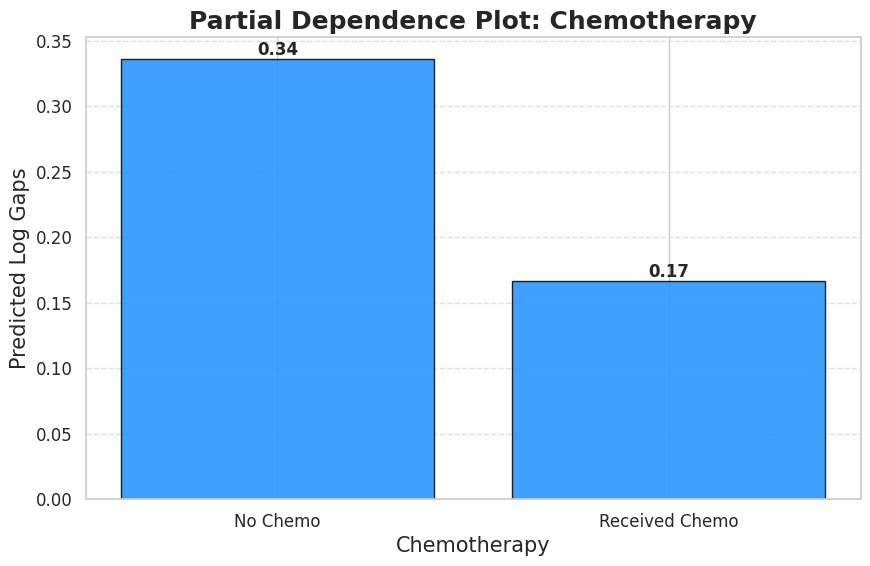

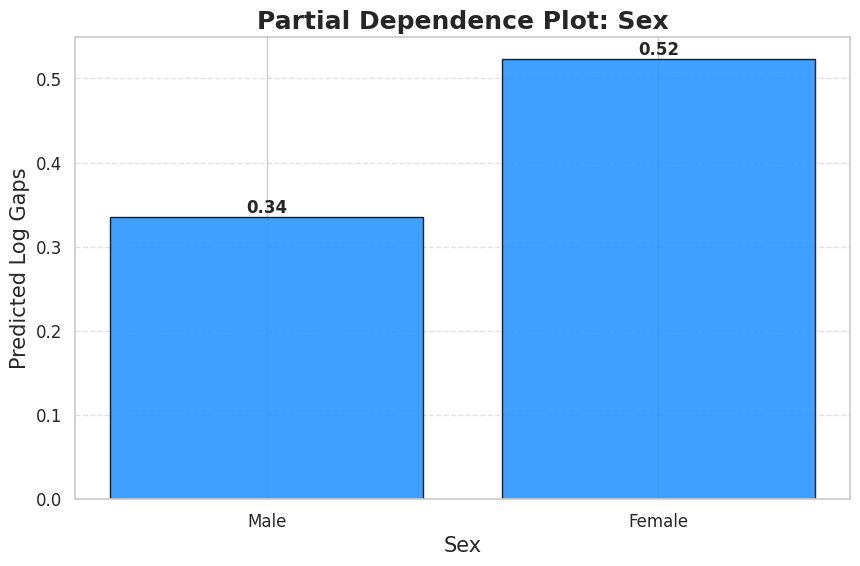

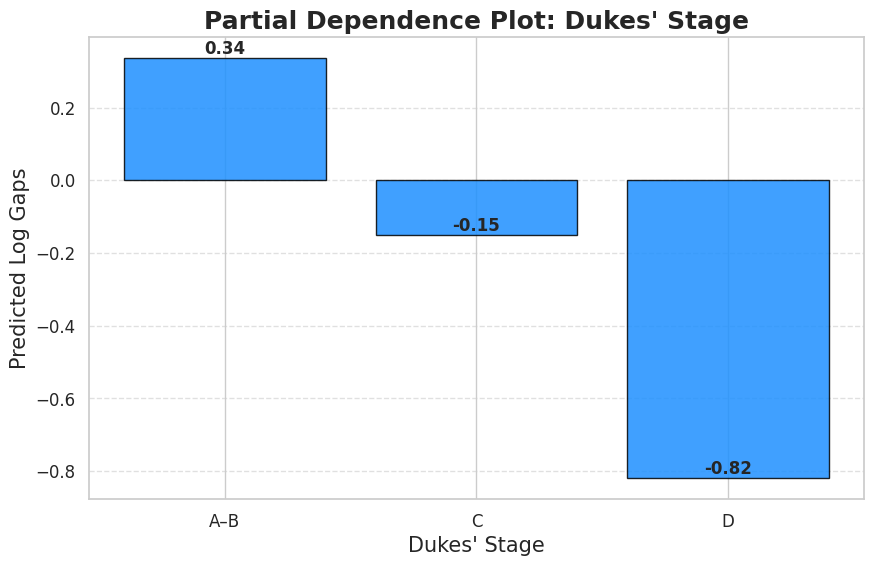

In [ ]:
!pip install lifelines
!pip install sympy==1.13.3

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# === Model & utilities (same core model as before, forward accepts concatenated input) ===

class RNNAFTGRU(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32, gru_layers=2, dropout=0.0):
        super().__init__()
        self.cov_dim = cov_dim
        self.input_dim = 1 + cov_dim
        self.hidden_dim = hidden_dim
        self.gru_layers = gru_layers

        self.gru = nn.GRU(
            input_size=self.input_dim,
            hidden_size=hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0.0
        )
        self.output = nn.Linear(hidden_dim, 1)
        self.init_fc = nn.Linear(cov_dim, gru_layers * hidden_dim)

    def initialize_hidden(self, X_static):
        h0_flat = torch.tanh(self.init_fc(X_static))
        h0 = h0_flat.view(self.gru_layers, X_static.size(0), self.hidden_dim)
        return h0

    def forward(self, X_in):
        # X_in: [batch, seq, 1 + cov_dim]
        covariates_seq = X_in[..., 1:]
        X_static = covariates_seq[:, 0, :]
        h0 = self.initialize_hidden(X_static)
        gru_out, h = self.gru(X_in, h0)
        yhat = self.output(gru_out).squeeze(-1)  # [batch, seq]
        return yhat, h

def batchify_subjects(subject_data: List[Dict], cov_dim: int):
    batch_size = len(subject_data)
    seq_lens = [len(s['log_gaps']) for s in subject_data]
    max_seq = max(seq_lens) if len(seq_lens) > 0 else 0
    prev_log_gaps = np.zeros((batch_size, max_seq, 1), dtype=np.float32)
    covariates = np.zeros((batch_size, max_seq, cov_dim), dtype=np.float32)
    log_gaps = np.zeros((batch_size, max_seq), dtype=np.float32)
    delta = np.zeros((batch_size, max_seq), dtype=np.float32)
    for i, s in enumerate(subject_data):
        l = seq_lens[i]
        if l == 0:
            continue
        if l > 1:
            prev_log_gaps[i, 1:l, 0] = s['log_gaps'][:-1]
        covariates[i, :l, :] = np.tile(s['covariates'], (l, 1))
        log_gaps[i, :l] = s['log_gaps']
        delta[i, :l] = s['delta']
    return (
        torch.tensor(prev_log_gaps, dtype=torch.float32),
        torch.tensor(covariates, dtype=torch.float32),
        torch.tensor(log_gaps, dtype=torch.float32),
        torch.tensor(delta, dtype=torch.float32),
        torch.tensor(seq_lens, dtype=torch.long)
    )

# === Gehan loss (full version left for reference) ===

class GehanLoss(nn.Module):
    """
    Original (full) Gehan loss that sums over all pairs. Kept for reference/testing.
    """
    def __init__(self, reduction='mean'):
        super().__init__()
        self.reduction = reduction

    def forward(self, pred_log_gaps, true_log_gaps, delta, seq_lens):
        device = pred_log_gaps.device
        batch, max_seq = pred_log_gaps.shape
        mask = (torch.arange(max_seq, device=device)[None, :] < seq_lens[:, None])
        events_mask = (delta == 1) & mask

        event_indices = events_mask.nonzero(as_tuple=False)
        if len(event_indices) == 0:
            return torch.tensor(0.0, requires_grad=True, device=device)

        e = true_log_gaps - pred_log_gaps  # residuals
        flat_e = e[mask]  # flatten only valid positions
        e_ij = e[event_indices[:, 0], event_indices[:, 1]]

        diffs = flat_e.unsqueeze(0) - e_ij.unsqueeze(1)  # [num_events, N_total]
        neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
        loss = neg_part.sum()
        if self.reduction == 'mean':
            loss = loss / event_indices.shape[0]
        return loss

# === Sub-sampling pairs utilities ===

def flatten_events(subjects: List[Dict]) -> Tuple[int, np.ndarray, np.ndarray, np.ndarray]:
    """
    Flatten events and provide mapping arrays.

    Returns:
      N_total: int (total number of event slots across subjects)
      subj_of_flat: np.array shape (N_total,) mapping flat_idx -> subject index i
      t_of_flat: np.array shape (N_total,) mapping flat_idx -> event time index j
      is_valid: np.array shape (N_total,) boolean - True if event exists (no padding)
    """
    seq_lens = [len(s['log_gaps']) for s in subjects]
    N_total = sum(seq_lens)
    subj_of_flat = np.empty(N_total, dtype=np.int32)
    t_of_flat = np.empty(N_total, dtype=np.int32)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1
    return N_total, subj_of_flat, t_of_flat

def sample_pairs_from_predictions(
    subjects: List[Dict],
    pred_log: np.ndarray,
    s: int,
    seed: int = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    For each uncensored residual (i,j) sample s indices from all other residuals
    (flat indexing). Returns arrays (I, J, L, K) each length m = n' * s, where
      (I[t], J[t]) is the left element (uncensored event),
      (L[t], K[t]) is the sampled counterpart.
    Sampling is uniform over other residuals excluding the same index.
    """
    rng = np.random.default_rng(seed)
    # Build flatten mapping and helpful arrays
    seq_lens = [len(su['log_gaps']) for su in subjects]
    prefix = np.concatenate([[0], np.cumsum(seq_lens)])
    N_total = int(prefix[-1])
    if N_total == 0:
        return (np.array([], dtype=int),) * 4

    # list of all flat indices
    all_flat = np.arange(N_total, dtype=int)

    # map from flat index to (i,j)
    subj_of_flat = np.empty(N_total, dtype=int)
    t_of_flat = np.empty(N_total, dtype=int)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1

    # gather uncensored flat indices
    uncensored_flats = []
    for i, ssub in enumerate(subjects):
        for j in range(len(ssub['log_gaps'])):
            if int(ssub['delta'][j]) == 1:
                flat_idx = prefix[i] + j
                uncensored_flats.append(flat_idx)
    uncensored_flats = np.array(uncensored_flats, dtype=int)
    n_prime = len(uncensored_flats)
    if n_prime == 0:
        return (np.array([], dtype=int),) * 4

    m = n_prime * s
    I = np.empty(m, dtype=int)
    J = np.empty(m, dtype=int)
    L = np.empty(m, dtype=int)
    K = np.empty(m, dtype=int)
    out_pos = 0
    for flat in uncensored_flats:
        # candidate pool excludes self
        pool = np.delete(all_flat, flat)
        replace = False if (pool.size >= s) else True
        chosen = rng.choice(pool, size=s, replace=replace)
        for ch in chosen:
            Ii = subj_of_flat[flat]
            Ji = t_of_flat[flat]
            Ll = subj_of_flat[ch]
            Kl = t_of_flat[ch]
            I[out_pos] = Ii
            J[out_pos] = Ji
            L[out_pos] = Ll
            K[out_pos] = Kl
            out_pos += 1
    return I, J, L, K

# === Metrics (unchanged from previous corrected implementation) ===

def pad_log_gaps(subjects, max_seq):
    n = len(subjects)
    arr = np.zeros((n, max_seq), dtype=np.float32)
    for i, s in enumerate(subjects):
        l = len(s['log_gaps'])
        arr[i, :l] = s['log_gaps']
    return arr

def compute_mse(subjects, pred_log):
    rows = []
    for i, subj in enumerate(subjects):
        for j in range(len(subj['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'log_gap': float(subj['log_gaps'][j]),
                'gap': float(np.exp(subj['log_gaps'][j])),
                'delta': int(subj['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    se = df['delta'] / df['G_hat'] * (df['log_gap'] - df['pred_log'])**2
    denom = df['delta'].sum()
    if denom == 0:
        return np.nan
    amse = se.sum() / denom
    return float(amse)

def ipcw_cindex(subjects, pred_log):
    rows = []
    for i, subj_i in enumerate(subjects):
        for j in range(len(subj_i['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'gap': float(np.exp(subj_i['log_gaps'][j])),
                'log_gap': float(subj_i['log_gaps'][j]),
                'delta': int(subj_i['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    num, denom = 0.0, 0.0
    for idx_i, row_i in df.iterrows():
        if row_i['delta'] != 1:
            continue
        for idx_k, row_k in df.iterrows():
            if row_i['i'] == row_k['i']:
                continue
            if row_i['gap'] < row_k['gap']:
                weight = 1.0 / row_i['G_hat'] if row_i['G_hat'] > 0 else 0.0
                concordant = 1.0 if row_i['pred_log'] < row_k['pred_log'] else 0.0
                num += weight * concordant
                denom += weight
    return float(num / denom) if denom > 0 else np.nan

# === Training with sub-sampled pairs ===

def train_rnn_aft_subsample_pairs(
    train_subjects,
    test_subjects,
    cov_dim=3,
    hidden_dim=32,
    epochs=10,
    pair_sample_s=2,
    pair_batch_b=64,
    lr=1e-3,
    device="cpu",
    seed=None
):
    device = torch.device(device)
    rng = np.random.default_rng(seed)
    model = RNNAFTGRU(cov_dim, hidden_dim=hidden_dim).to(device)
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    n_train = len(train_subjects)
    train_losses = []
    train_mse_hist = []
    test_mse_hist = []
    train_cidx_hist = []
    test_cidx_hist = []

    def predict_all_numpy(subjects):
        if len(subjects) == 0:
            return np.zeros((0, 0), dtype=np.float32)
        n = len(subjects)
        max_seq = max([len(s['log_gaps']) for s in subjects])
        X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(subjects, cov_dim)
        X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
        with torch.no_grad():
            yhat, _ = model(X_in)
        pred_log = yhat.cpu().numpy()
        out = np.zeros_like(pred_log)
        for i in range(n):
            out[i, :seq_lens[i]] = pred_log[i, :seq_lens[i]]
        return out

    for epoch in range(epochs):
        model.train()
        # Step 1: snapshot predictions to sample pairs (use numpy snapshot)
        pred_log_train_snapshot = predict_all_numpy(train_subjects)

        # Step 2: sample pairs (m = n' * s)
        I, J, L, K = sample_pairs_from_predictions(train_subjects, pred_log_train_snapshot, pair_sample_s, seed=rng.integers(1_000_000))
        m = I.size
        # If nothing was sampled (no uncensored events), fall back to no-op update pass
        if m == 0:
            print(f"Epoch {epoch+1}: no uncensored events found, skipping pair-subsampling updates.")
            train_losses.append(0.0)
            train_mse_hist.append(compute_mse(train_subjects, pred_log_train_snapshot))
            test_mse_hist.append(compute_mse(test_subjects, predict_all_numpy(test_subjects)))
            train_cidx_hist.append(ipcw_cindex(train_subjects, pred_log_train_snapshot))
            test_cidx_hist.append(ipcw_cindex(test_subjects, predict_all_numpy(test_subjects)))
            continue

        # shuffle sampled pairs
        perm_pairs = rng.permutation(m)
        I, J, L, K = I[perm_pairs], J[perm_pairs], L[perm_pairs], K[perm_pairs]

        # Precompute some constants for weighting
        N_total = sum(len(s['log_gaps']) for s in train_subjects)
        # number of uncensored events n'
        n_prime = int(np.sum([np.sum(s['delta']) for s in train_subjects]))

        # per-epoch optimization over sampled pairs mini-batches
        losses_epoch = []
        # iterate mini-batches of pairs
        for start in range(0, m, pair_batch_b):
            end = min(start + pair_batch_b, m)
            batch_slice = slice(start, end)
            Ib, Jb, Lb, Kb = I[batch_slice], J[batch_slice], L[batch_slice], K[batch_slice]

            # find unique subject indices in this pairs-batch
            unique_subjects, inv_idx = np.unique(np.concatenate([Ib, Lb]), return_inverse=True)
            # map global subject idx -> local index
            g2l = {int(g): int(l) for l, g in enumerate(unique_subjects)}
            # build small sub-batch of subjects
            sub_subjects = [train_subjects[int(g)] for g in unique_subjects]
            X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(sub_subjects, cov_dim)
            X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
            Y_log_gaps = Y_log_gaps.to(device)
            Y_delta = Y_delta.to(device)
            seq_lens_t = seq_lens.to(device)

            optimizer.zero_grad()
            yhat_sub, _ = model(X_in)  # [n_sub, max_sub_seq]
            # For each pair we need predicted log for left and right
            # Build tensors of predictions corresponding to pairs
            left_preds = []
            right_preds = []
            left_trues = []
            right_trues = []
            for idx_pair in range(Ib.size):
                gi = int(Ib[idx_pair]); gj = int(Jb[idx_pair])
                gl = int(Lb[idx_pair]); gk = int(Kb[idx_pair])
                li = g2l[gi]; ll = g2l[gl]
                # grab as torch scalars
                # Note: ensure event index within seq_lens for sub-batch (should be by construction)
                pred_ij = yhat_sub[li, gj]
                pred_lk = yhat_sub[ll, gk]
                left_preds.append(pred_ij)
                right_preds.append(pred_lk)
                left_trues.append(torch.tensor(float(train_subjects[gi]['log_gaps'][gj]), device=device))
                right_trues.append(torch.tensor(float(train_subjects[gl]['log_gaps'][gk]), device=device))
            left_preds = torch.stack(left_preds)  # [batch_pairs_in_minibatch]
            right_preds = torch.stack(right_preds)
            left_trues = torch.stack(left_trues)
            right_trues = torch.stack(right_trues)

            # residuals e = true - pred
            e_ij = left_trues - left_preds
            e_lk = right_trues - right_preds
            diffs = e_lk - e_ij
            neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
            sum_neg = neg_part.sum()

            # scaling for unbiased estimator:
            # For each uncensored event we sampled s from N_total - 1 possibilities. So factor = (N_total - 1) / s
            # Our overall GehanLoss with reduction='mean' divides by n' (#uncensored events).
            scale = float((N_total - 1) / max(1, pair_sample_s))
            loss_batch = sum_neg * scale
            if n_prime > 0:
                loss_batch = loss_batch / float(n_prime)
            # backpropagate
            loss_batch.backward()
            optimizer.step()
            losses_epoch.append(float(loss_batch.detach().cpu().numpy()))

        mean_epoch_loss = float(np.mean(losses_epoch)) if len(losses_epoch) > 0 else 0.0
        train_losses.append(mean_epoch_loss)

        # Evaluate on train and test sets (use current model to predict)
        model.eval()
        pred_log_train = predict_all_numpy(train_subjects)
        pred_log_test = predict_all_numpy(test_subjects)
        mse_train = compute_mse(train_subjects, pred_log_train)
        mse_test = compute_mse(test_subjects, predict_all_numpy(test_subjects))
        train_mse_hist.append(mse_train)
        test_mse_hist.append(mse_test)
        cidx_train = ipcw_cindex(train_subjects, pred_log_train)
        cidx_test = ipcw_cindex(test_subjects, predict_all_numpy(test_subjects))
        train_cidx_hist.append(cidx_train)
        test_cidx_hist.append(cidx_test)

        print(f"Epoch {epoch + 1}/{epochs} | SamplePairs m={m} | Mean Pair-Batch Loss: {mean_epoch_loss:.4f} | Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f} | Train C-index: {np.nan_to_num(cidx_train):.3f} | Test C-index: {np.nan_to_num(cidx_test):.3f}")

    # final evaluation
    model.eval()
    pred_log_train = predict_all_numpy(train_subjects)
    pred_log_test = predict_all_numpy(test_subjects)
    mse_train = compute_mse(train_subjects, pred_log_train)
    mse_test = compute_mse(test_subjects, pred_log_test)
    cidx_train = ipcw_cindex(train_subjects, pred_log_train)
    cidx_test = ipcw_cindex(test_subjects, pred_log_test)

    return {
        "model": model,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "cindex_train": cidx_train,
        "cindex_test": cidx_test,
        "pred_log_train": pred_log_train,
        "pred_log_test": pred_log_test,
        "train_losses": train_losses,
        "train_mse_hist": train_mse_hist,
        "test_mse_hist": test_mse_hist,
        "train_cidx_hist": train_cidx_hist,
        "test_cidx_hist": test_cidx_hist,
    }


# === Step 1: Load and Prepare the Dataset ===
def load_and_prepare_dataset(file_path, time_fixed_columns, gap_time_column, event_column):
    """
    Load the dataset and extract the relevant columns.

    Parameters:
        file_path: str
            Path to the CSV file containing the dataset.
        time_fixed_columns: list of str
            List of names for the time-fixed covariates.
        gap_time_column: str
            Name of the gap time column.
        event_column: str
            Name of the censoring status column (1 = observed, 0 = censored).

    Returns:
        dataset: pd.DataFrame
            A preprocessed DataFrame with the necessary columns.
    """
    # Load the dataset
    dataset = pd.read_csv(file_path)

    # Keep only the relevant columns
    dataset = dataset[time_fixed_columns + [gap_time_column, event_column]]

    # Rename columns for consistency
    dataset.columns = time_fixed_columns + ["gap_time", "event"]

    return dataset

# === Step 2: Convert the Dataset into Gaps and NN-Compatible Format ===
def prepare_data_for_nn(dataset, time_fixed_columns=("Z1", "Z2", "Z3")):
    """
    Prepare the dataset for use with the RNN-AFT model.

    Parameters:
        dataset: pd.DataFrame
            The dataset containing covariates, gap times, and event indicators.
        time_fixed_columns: list of str
            List of names for the time-fixed covariates.

    Returns:
        subjects: list of dict
            List of dictionaries formatted for the RNN-AFT model.
    """
    subjects = []
    for _, row in dataset.iterrows():
        covariates = row[time_fixed_columns].values.astype(np.float32)
        log_gaps = [np.log(row["gap_time"])]
        delta = [int(row["event"])]  # 1 (observed) or 0 (censored)
        subjects.append({
            "covariates": covariates,
            "log_gaps": log_gaps,
            "delta": delta,
        })
    return subjects

# === Step 3: Main Runner to Train the Model ===
def train_rnn_aft_on_real_data(
    dataset_path, time_fixed_columns, gap_time_column, event_column,
    train_split=0.7, hidden_dim=32, epochs=10, pair_sample_s=10,
    pair_batch_b=64, lr=1e-3, device="cpu", seed=42
):
    """
    Train the RNN-AFT model on a real dataset using only time-fixed covariates.

    Parameters:
        dataset_path: str
            Path to the dataset CSV file.
        time_fixed_columns: list of str
            List of names for time-fixed covariates (e.g., ["Z1", "Z2", "Z3"]).
        gap_time_column: str
            Name of the gap time column.
        event_column: str
            Name of the censoring status column.
        train_split: float
            Proportion of data to use for training.
        hidden_dim: int
            Number of GRU hidden dimensions.
        epochs: int
            Number of training epochs.
        pair_sample_s: int
            Number of pairs per uncensored residual.
        pair_batch_b: int
            Mini-batch size during training.
        lr: float
            Learning rate.
        device: str
            Device to run the model (e.g., "cpu" or "cuda").
        seed: int
            Random seed for reproducibility.
    """
    # Load and preprocess the dataset
    dataset = load_and_prepare_dataset(
        dataset_path, time_fixed_columns, gap_time_column, event_column
    )

    # Split into train and test sets
    train_data, test_data = train_test_split(dataset, train_size=train_split, random_state=seed)

    # Convert data to NN-compatible format
    train_subjects = prepare_data_for_nn(train_data, time_fixed_columns)
    test_subjects = prepare_data_for_nn(test_data, time_fixed_columns)

    # Train the RNN-AFT model
    results = train_rnn_aft_subsample_pairs(
        train_subjects, test_subjects,
        cov_dim=len(time_fixed_columns), hidden_dim=hidden_dim, epochs=epochs,
        pair_sample_s=pair_sample_s, pair_batch_b=pair_batch_b, lr=lr, device=device, seed=seed
    )

    # Print results
    print("\nFinal Results:")
    print(f"Train MSE: {results['mse_train']:.4f}")
    print(f"Test MSE: {results['mse_test']:.4f}")
    print(f"Train IPCW C-index: {results['cindex_train']:.4f}")
    print(f"Test IPCW C-index: {results['cindex_test']:.4f}")

    return results


def isolate_pdp_feature(model, subjects, covariate, covariate_idx, values, fixed_values, cov_dim):
    """
    Isolate Partial Dependence Predictions for a specific feature.

    Parameters:
        model: Trained RNN-AFT model.
            The trained PyTorch model.
        subjects: List[dict]
            Test dataset formatted for RNN-AFT model input.
        covariate: str
            The name of the covariate being analyzed for PDP.
        covariate_idx: int
            The index of the covariate in the dataset.
        values: list
            List of values/ranges to isolate for the selected covariate.
        fixed_values: list
            Fixed values for other covariates.
        cov_dim: int
            Total number of covariates.

    Returns:
        pd.DataFrame:
            A DataFrame containing isolated PDP predictions for the covariate.
    """
    predictions = []  # Store predicted log gaps for each value
    for value in values:
        # Manipulate the dataset to isolate the covariate
        manipulated_subjects = []
        for subj in subjects:
            manipulated_subj = subj.copy()
            manipulated_subj["covariates"] = fixed_values.copy()  # Set fixed values for all covariates
            manipulated_subj["covariates"][covariate_idx] = value  # Change the covariate value
            manipulated_subjects.append(manipulated_subj)

        # Prepare model inputs via batchify
        X_prev_gaps, X_cov, _, _, seq_lens = batchify_subjects(manipulated_subjects, cov_dim)
        X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to("cpu")

        # Predict the log gaps
        with torch.no_grad():
            pred, _ = model(X_in)
        predictions.append(pred.mean().item())  # Aggregate predictions (mean)

    # Return predictions as a DataFrame with corresponding values
    return pd.DataFrame({covariate: values, "mean_pred": predictions})


def plot_isolated_pdp(pdp_data, feature_name, level_labels, center=False, engine="matplotlib", figheight=6):
    """
    Plot PDP for an isolated feature.

    Parameters:
        pdp_data: pd.DataFrame
            The isolated PDP data as a DataFrame with columns [feature, mean_pred].
        feature_name: str
            Descriptive name of the feature being analyzed.
        level_labels: list
            Descriptive labels for the categorical levels of the feature being analyzed.
        center: bool
            Whether to center the PDP on the average prediction.
        engine: str
            The plotting engine (only 'matplotlib' is supported in this example).
        figheight: int
            Height of the plot.

    Returns:
        None (Visualizes the PDP plot).
    """
    # Center the predictions if required
    if center:
        pdp_data["centered_pred"] = pdp_data["mean_pred"] - pdp_data["mean_pred"].mean()

    # Select column to plot
    prediction_col = "centered_pred" if center else "mean_pred"

    if engine == "matplotlib":
        # Plot using matplotlib
        plt.figure(figsize=(10, figheight))
        bars = plt.bar(
            level_labels,  # Map numerical values to descriptive levels
            pdp_data[prediction_col],
            color="dodgerblue", edgecolor="black", alpha=0.85
        )

        # Add annotations for the bar values
        for bar in bars:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=12, fontweight="bold"
            )

        plt.title(f"Partial Dependence Plot: {feature_name}", fontsize=18, fontweight="bold")
        plt.xlabel(feature_name, fontsize=15)
        plt.ylabel("Predicted Log Gaps" if not center else "Centered Predicted Log Gaps", fontsize=15)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.grid(axis="y", linestyle="--", alpha=0.6)
        plt.show()

if __name__ == "__main__":
    # Define dataset parameters and covariates
    dataset_path = "/content/drive/MyDrive/Colab Notebooks/data_cp.csv"  # Path to your dataset
    time_fixed_columns = ["Z1", "Z2", "Z3"]  # Covariate labels consistent with dataset
    gap_time_column = "gap_time"  # Name of the gap time column
    event_column = "event"  # Name of the censoring status column (1 = observed, 0 = censored)

    # Covariate values and labels
    internal_covariates = ["Z1", "Z2", "Z3"]  # Dataset column names
    covariate_names = {  # Map internal dataset labels to descriptive names
        "Z1": "Chemotherapy",
        "Z2": "Sex",
        "Z3": "Dukes' Stage"
    }
    covariate_values = {
        "Z1": [0, 1],  # Chemotherapy: 0 = No Chemo, 1 = Received Chemo
        "Z2": [0, 1],  # Sex: 0 = Male, 1 = Female
        "Z3": [1, 2, 3],  # Dukes' Stage: 1 = A-B, 2 = C, 3 = D
    }
    covariate_level_labels = {
        "Z1": ["No Chemo", "Received Chemo"],  # Human-readable labels for Chemotherapy
        "Z2": ["Male", "Female"],  # Labels for Sex
        "Z3": ["A–B", "C", "D"],  # Labels for Dukes' Stage
    }

    # Split dataset into train/test
    dataset = load_and_prepare_dataset(
        dataset_path, time_fixed_columns, gap_time_column, event_column
    )
    train_split = 0.7
    train_data, test_data = train_test_split(dataset, train_size=train_split, random_state=42)

    # Prepare test dataset for RNN model
    test_subjects = prepare_data_for_nn(test_data, time_fixed_columns)

    # Fixed values for other covariates (set their default values)
    fixed_values = [0, 0, 1]  # Default: No chemo (Z1), Male (Z2), Dukes' Stage A-B (Z3)

    # Train the RNN model if not pre-trained
    model = train_rnn_aft_on_real_data(
        dataset_path=dataset_path,
        time_fixed_columns=time_fixed_columns,
        gap_time_column=gap_time_column,
        event_column=event_column,
        train_split=train_split,
        hidden_dim=32,
        epochs=10,
        pair_sample_s=10,
        pair_batch_b=64,
        lr=1e-3,
        device="cpu",
        seed=42
    )["model"]

    # Generate PDPs for each covariate
    for covariate in internal_covariates:
        # Isolate PDP for the covariate
        pdp_data = isolate_pdp_feature(
            model=model,
            subjects=test_subjects,
            covariate=covariate,
            covariate_idx=internal_covariates.index(covariate),
            values=covariate_values[covariate],
            fixed_values=fixed_values,
            cov_dim=len(internal_covariates)  # Pass the length of covariates
        )

        # Plot PDP using descriptive covariate name
        descriptive_name = covariate_names[covariate]  # Get the descriptive name (e.g., "Chemotherapy")
        plot_isolated_pdp(
            pdp_data=pdp_data,
            feature_name=descriptive_name,  # Use descriptive covariate name in plot
            level_labels=covariate_level_labels[covariate],  # Use human-readable levels
            center=False
        )

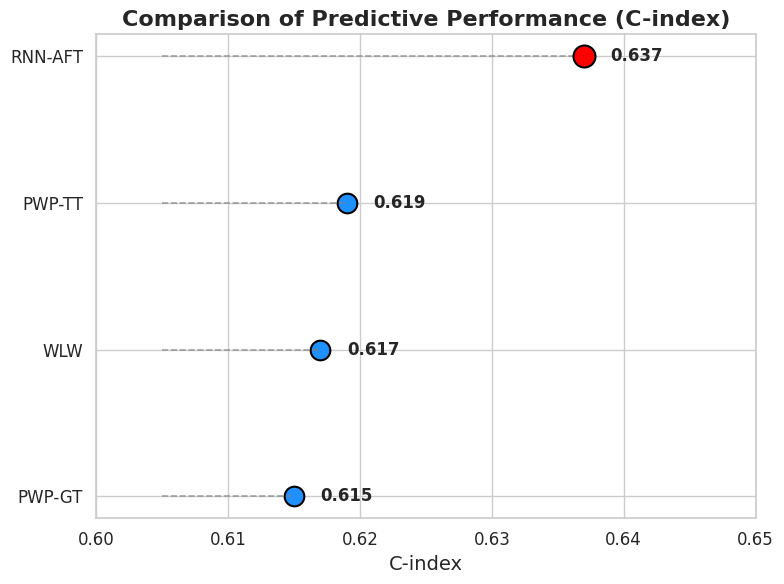

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data (including WLW)
data = {
    "Model": ["RNN-AFT", "PWP-GT", "PWP-TT", "WLW"],
    "C-index": [0.637, 0.615, 0.619, 0.617]
}
cindex_data = pd.DataFrame(data)

# Sort data by C-index in ascending order
cindex_data = cindex_data.sort_values(by="C-index", ascending=False).reset_index(drop=True)

# Identify the best model
best_model_index = cindex_data["C-index"].idxmax()  # Index of the highest C-index value
best_model = cindex_data.iloc[best_model_index]  # Row for the best model

# Create the plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Create a point plot
point_plot = sns.scatterplot(
    data=cindex_data,
    x="C-index",
    y="Model",
    s=200,
    color="dodgerblue",
    edgecolor="black",
    linewidth=1.5
)

# Highlight the best model in red
plt.scatter(
    x=best_model["C-index"],
    y=best_model_index,
    color="red",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    zorder=5  # Ensure it is drawn on top
)

# Draw horizontal lines for better comparison
for i in range(len(cindex_data)):
    plt.hlines(
        y=i,
        xmin=cindex_data["C-index"].min() - 0.01,  # Extend slightly for aesthetics
        xmax=cindex_data["C-index"][i],
        color="gray",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7
    )

# Annotate the C-index next to each point
for i, row in cindex_data.iterrows():
    plt.text(
        x=row["C-index"] + 0.002,
        y=i,
        s=f"{row['C-index']:.3f}",
        va='center',
        ha='left',
        fontsize=12,
        fontweight='bold'
    )

# Customize the plot
plt.title("", fontsize=16, fontweight="bold")
plt.xlabel("C-index", fontsize=14)
plt.ylabel("")  # Remove the y-axis label
plt.xlim(0.6, 0.65)  # Set limits for better focus on comparisons
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()